<a href="https://colab.research.google.com/github/sesabe10/Ciencia-de-datos/blob/main/Copia_de_Laboratorio_Transf_caracteristicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Transformación de características
# Escalamiento
# Min-Max Scaling y Estandarización (Z-Score)

In [1]:
# =========================================
# OBJETIVO
# =========================================
# Comprender cómo funcionan las transformaciones de escalamiento
# y cómo afectan los datos en análisis y modelos.

In [ ]:
# =========================================
# 📘 PARTE 1: CONCEPTO TEÓRICO
# =========================================

In [ ]:
# Min-Max Scaling:
# Lleva los datos a un rango entre 0 y 1
# Fórmula:
# X' = (X - min) / (max - min)

# Z-Score:
# Centra los datos en 0 usando la media
# Fórmula:
# Z = (X - media) / desviación estándar

In [ ]:
# =========================================
# 📊 PARTE 2: CASO DE USO
# =========================================

# Supongamos que tenemos datos de clientes
# Problema: ingresos domina sobre edad

In [2]:
import pandas as pd

# Dataset base

data = pd.DataFrame({
    'edad': [20, 25, 30, 40, 50],
    'ingreso': [1000000, 1500000, 3000000, 7000000, 10000000]
})

print("\n📊 Datos originales:\n")
print(data)


📊 Datos originales:

   edad   ingreso
0    20   1000000
1    25   1500000
2    30   3000000
3    40   7000000
4    50  10000000


In [3]:
# =========================================
# 🔹 PARTE 3: MIN-MAX SCALING
# =========================================

from sklearn.preprocessing import MinMaxScaler

# Creamos el escalador
scaler = MinMaxScaler()

# Aplicamos transformación
minmax_data = scaler.fit_transform(data)

# Convertimos a DataFrame
minmax_df = pd.DataFrame(minmax_data, columns=data.columns)

print("\n🔹 Datos con Min-Max Scaling:\n")
print(minmax_df)

# 💡 Observa:
# - Todos los valores están entre 0 y 1
# - Se mantiene la proporción


🔹 Datos con Min-Max Scaling:

       edad   ingreso
0  0.000000  0.000000
1  0.166667  0.055556
2  0.333333  0.222222
3  0.666667  0.666667
4  1.000000  1.000000


In [4]:
# =========================================
# 🔹 PARTE 4: Z-SCORE (ESTANDARIZACIÓN)
# =========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

zscore_data = scaler.fit_transform(data)

zscore_df = pd.DataFrame(zscore_data, columns=data.columns)

print("\n🔹 Datos con Z-Score:\n")
print(zscore_df)

# 💡 Observa:
# - Valores alrededor de 0
# - Negativos = debajo del promedio
# - Positivos = encima del promedio


🔹 Datos con Z-Score:

       edad   ingreso
0 -1.207020 -1.010363
1 -0.742781 -0.866025
2 -0.278543 -0.433013
3  0.649934  0.721688
4  1.578410  1.587713


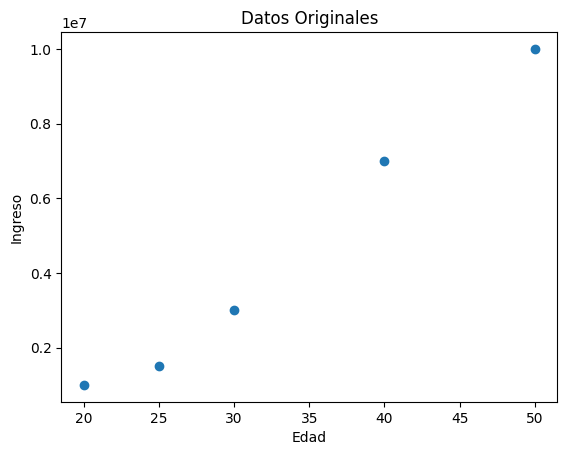

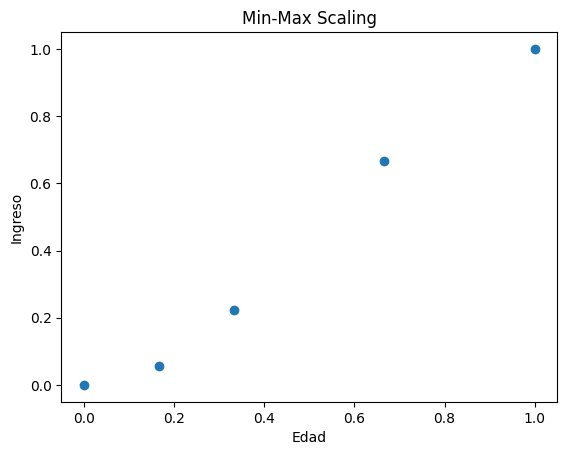

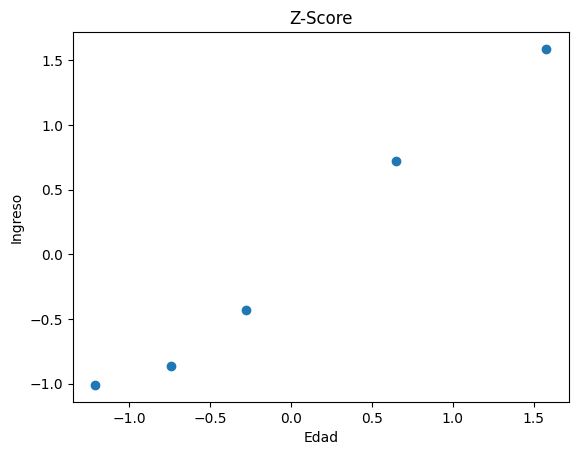

In [5]:
# =========================================
# 🧪 PARTE 5: VISUALIZACIÓN
# =========================================

#“Comparar cómo cambian los datos antes y después de aplicar transformaciones”

import matplotlib.pyplot as plt

# Datos originales
plt.scatter(data['edad'], data['ingreso'])
plt.title("Datos Originales")
plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.show()

# MinMax
plt.scatter(minmax_df['edad'], minmax_df['ingreso'])
plt.title("Min-Max Scaling")
plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.show()

# Z-score
plt.scatter(zscore_df['edad'], zscore_df['ingreso'])
plt.title("Z-Score")
plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.show()


In [ ]:
# =========================================
# PARTE 6: ACTIVIDAD
# =========================================

# Ejercicio 1:
# Cambia los valores de ingreso agregando un valor extremo (outlier)
# Ejemplo: 50000000

# Pregunta:
# ¿Qué pasa con Min-Max?
# ¿Qué pasa con Z-score?

# =========================================
# Responde: Escribe las conclusiones


Original:
    edad   ingreso
0    20   1000000
1    25   1500000
2    30   3000000
3    40   7000000
4    50  50000000

Min-Max con outlier:
     edad  ingreso
0  0.000    0.000
1  0.167    0.010
2  0.333    0.041
3  0.667    0.122
4  1.000    1.000

Z-Score con outlier:
     edad  ingreso
0 -1.207   -0.609
1 -0.743   -0.583
2 -0.279   -0.503
3  0.650   -0.291
4  1.578    1.987


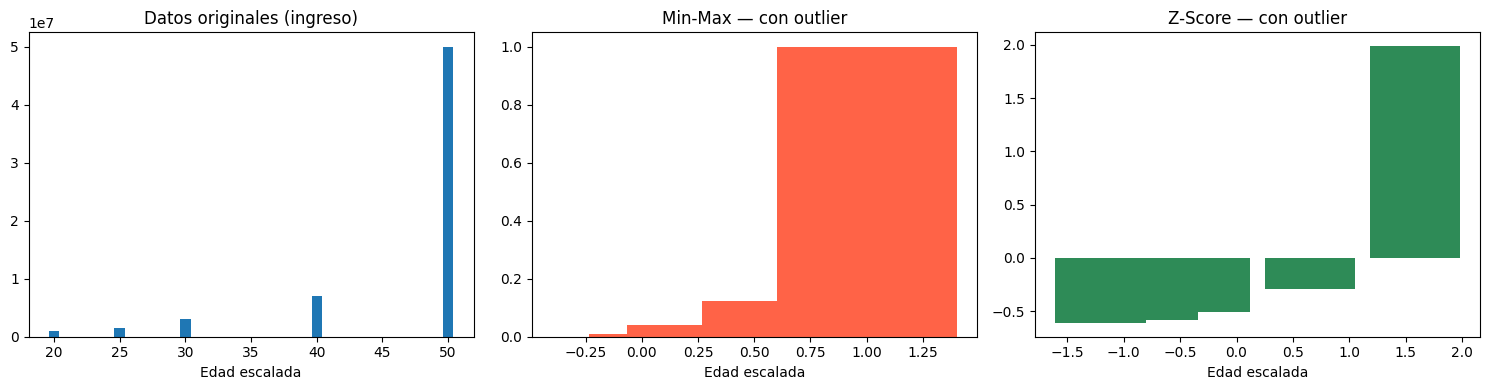

In [9]:
# Dataset con outlier
data_outlier = pd.DataFrame({
    'edad': [20, 25, 30, 40, 50],
    'ingreso': [1000000, 1500000, 3000000, 7000000, 50000000]
})

# Aplicar Min-Max
scaler_mm = MinMaxScaler()
minmax_out = pd.DataFrame(
    scaler_mm.fit_transform(data_outlier),
    columns=data_outlier.columns
)

# Aplicar Z-Score
scaler_z = StandardScaler()
zscore_out = pd.DataFrame(
    scaler_z.fit_transform(data_outlier),
    columns=data_outlier.columns
)

print("Original:\n", data_outlier)
print("\nMin-Max con outlier:\n", minmax_out.round(3))
print("\nZ-Score con outlier:\n", zscore_out.round(3))

# Visualización comparativa
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].bar(data_outlier['edad'], data_outlier['ingreso'])
axs[0].set_title("Datos originales (ingreso)")
axs[1].bar(minmax_out['edad'], minmax_out['ingreso'], color='tomato')
axs[1].set_title("Min-Max — con outlier")
axs[2].bar(zscore_out['edad'], zscore_out['ingreso'], color='seagreen')
axs[2].set_title("Z-Score — con outlier")
for ax in axs:
    ax.set_xlabel("Edad escalada")
plt.tight_layout()
plt.show()

# Conclusiones ejercicio 1:
Con un outlier de 50 millones, Min-Max aplasta todos los demás valores cerca de 0 (el mayor ocupa casi todo el rango 0–1). Z-Score también se afecta, pero distribuye mejor la variación. Para datos con outliers, Z-Score es más robusto.

In [ ]:
# =========================================
# Ejercicio 2:
# Elimina la columna ingreso y prueba solo con edad

# Pregunta:
# ¿Tiene sentido escalar una sola variable?

# =========================================
# Responde: Escribe las conclusiones


Edad original:
 [20 25 30 40 50]

Edad Min-Max:
 [0.    0.167 0.333 0.667 1.   ]

Edad Z-Score:
 [-1.207 -0.743 -0.279  0.65   1.578]


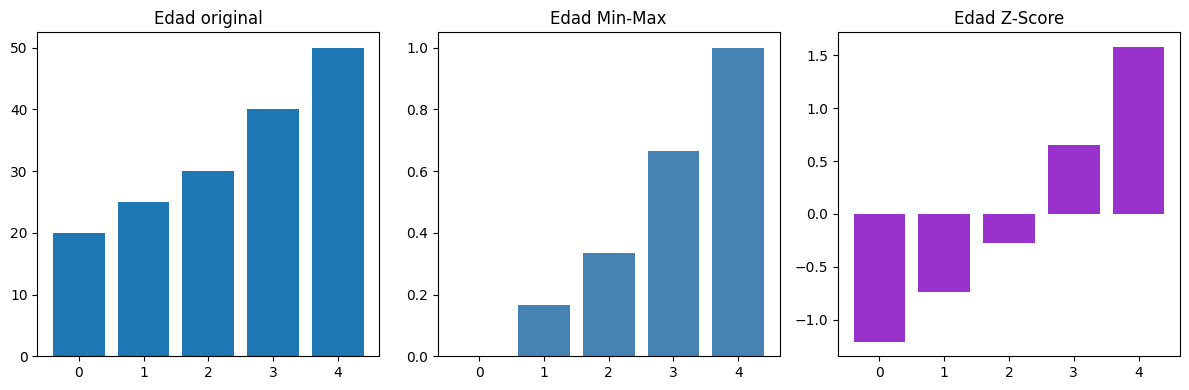

In [10]:
data_solo_edad = data_outlier[['edad']]

minmax_edad = pd.DataFrame(
    MinMaxScaler().fit_transform(data_solo_edad),
    columns=['edad']
)
zscore_edad = pd.DataFrame(
    StandardScaler().fit_transform(data_solo_edad),
    columns=['edad']
)

print("Edad original:\n", data_solo_edad.values.flatten())
print("\nEdad Min-Max:\n", minmax_edad.values.flatten().round(3))
print("\nEdad Z-Score:\n", zscore_edad.values.flatten().round(3))

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].bar(range(5), data_solo_edad['edad'])
axs[0].set_title("Edad original")
axs[1].bar(range(5), minmax_edad['edad'], color='steelblue')
axs[1].set_title("Edad Min-Max")
axs[2].bar(range(5), zscore_edad['edad'], color='darkorchid')
axs[2].set_title("Edad Z-Score")
plt.tight_layout()
plt.show()

# Conclusiones ejercicio 2:
Escalar una sola variable tiene sentido solo si se combina con otras variables escaladas en un modelo (para que todas estén en la misma escala). Si la usas sola, el escalamiento no cambia la forma de la distribución ni las relaciones.

In [ ]:
# =========================================
# Ejercicio 3:
# Crea una nueva variable llamada "gasto" y aplica ambas transformaciones

# Pregunta:
# ¿Cuál método funciona mejor?

# =========================================
# Responde: Escribe las conclusiones


Datos originales:
    edad   ingreso    gasto
0    20   1000000   500000
1    25   1500000   800000
2    30   3000000  1200000
3    40   7000000  2000000
4    50  10000000  4500000

Min-Max:
     edad  ingreso  gasto
0  0.000    0.000  0.000
1  0.167    0.056  0.075
2  0.333    0.222  0.175
3  0.667    0.667  0.375
4  1.000    1.000  1.000

Z-Score:
     edad  ingreso  gasto
0 -1.207   -1.010 -0.902
1 -0.743   -0.866 -0.694
2 -0.279   -0.433 -0.416
3  0.650    0.722  0.139
4  1.578    1.588  1.874


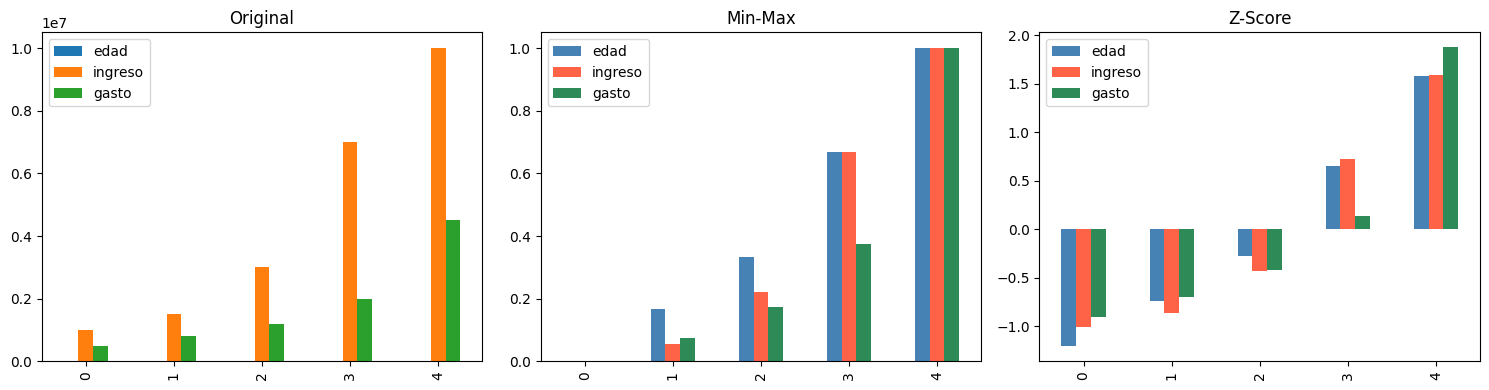


--- Estadísticas Min-Max ---
        edad  ingreso  gasto
count  5.000    5.000  5.000
mean   0.433    0.389  0.325
std    0.401    0.430  0.403
min    0.000    0.000  0.000
25%    0.167    0.056  0.075
50%    0.333    0.222  0.175
75%    0.667    0.667  0.375
max    1.000    1.000  1.000

--- Estadísticas Z-Score ---
        edad  ingreso  gasto
count  5.000    5.000  5.000
mean   0.000    0.000  0.000
std    1.118    1.118  1.118
min   -1.207   -1.010 -0.902
25%   -0.743   -0.866 -0.694
50%   -0.279   -0.433 -0.416
75%    0.650    0.722  0.139
max    1.578    1.588  1.874


In [11]:
data_gasto = pd.DataFrame({
    'edad':    [20, 25, 30, 40, 50],
    'ingreso': [1000000, 1500000, 3000000, 7000000, 10000000],
    'gasto':   [500000, 800000, 1200000, 2000000, 4500000]
})


minmax_gasto = pd.DataFrame(
    MinMaxScaler().fit_transform(data_gasto),
    columns=data_gasto.columns
)

zscore_gasto = pd.DataFrame(
    StandardScaler().fit_transform(data_gasto),
    columns=data_gasto.columns
)

print("Datos originales:\n", data_gasto)
print("\nMin-Max:\n", minmax_gasto.round(3))
print("\nZ-Score:\n", zscore_gasto.round(3))


fig, axs = plt.subplots(1, 3, figsize=(15, 4))
data_gasto.plot(kind='bar', ax=axs[0], title="Original")
minmax_gasto.plot(kind='bar', ax=axs[1], title="Min-Max", color=['steelblue','tomato','seagreen'])
zscore_gasto.plot(kind='bar', ax=axs[2], title="Z-Score", color=['steelblue','tomato','seagreen'])
plt.tight_layout()
plt.show()

print("\n--- Estadísticas Min-Max ---")
print(minmax_gasto.describe().round(3))
print("\n--- Estadísticas Z-Score ---")
print(zscore_gasto.describe().round(3))

# Conclusión del ejercicio 3:
Ambos métodos funcionan bien cuando no hay outliers. Min-Max pone todo en [0, 1], lo que es útil para algoritmos como KNN o redes neuronales. Z-Score centra todo en 0 con desviación estándar 1, lo que funciona mejor para regresión o SVM. El gasto tiene una relación proporcional al ingreso, por lo que ambos métodos preservan esa estructura relativa.

In [ ]:
# =========================================
# CONCLUSIÓN
# =========================================

# Min-Max:
# ✔ Útil cuando no hay outliers

# Z-Score:
# ✔ Mejor cuando hay valores extremos

# IDEA CLAVE:
# La transformación depende del tipo de datos

# Creando la primer APP Web de Transformación

In [27]:
#PASO 0
!pip install streamlit

In [20]:
#PASO 1
%%writefile app.py
# =========================================
# 🚀 APP STREAMLIT: ESCALAMIENTO INTERACTIVO
# =========================================
# Ejecutar con:
# streamlit run app.py

import streamlit as st
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

st.title("Escalamiento de Datos Interactivo")

# Crear dataset simple
st.sidebar.header("Configuración de datos")
n = st.sidebar.slider("Número de datos", 5, 100, 20)

np.random.seed(42)
data = pd.DataFrame({
    'edad': np.random.randint(18, 60, n),
    'ingreso': np.random.randint(1000000, 10000000, n)
})

st.subheader("📊 Datos originales")
st.write(data)

# Selección de transformación
option = st.selectbox("Selecciona transformación:", ["Min-Max", "Z-Score"])

if option == "Min-Max":
    scaler = MinMaxScaler()
    transformed = scaler.fit_transform(data)
    st.success("Aplicando Min-Max Scaling")
else:
    scaler = StandardScaler()
    transformed = scaler.fit_transform(data)
    st.success("Aplicando Z-Score")

transformed_df = pd.DataFrame(transformed, columns=data.columns)

st.subheader("📈 Datos transformados")
st.write(transformed_df)

# Visualización
fig, ax = plt.subplots()
ax.scatter(transformed_df['edad'], transformed_df['ingreso'])
ax.set_title("Visualización de datos transformados")
st.pyplot(fig)


# Visualización 2
plt.scatter(data['edad'], data['ingreso'])
plt.title("Datos originales")
plt.show()

st.write("\n🎯 Fin del laboratorio interactivo")


Overwriting app.py


In [13]:
#PASO 2
!streamlit run app.py &>/dev/null &

In [14]:
#PASO 3
!lsof -i:8501

In [28]:
# PASO 4 - Versión corregida
# Instalar cloudflared
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!mv cloudflared /usr/local/bin/

# Lanzar la app primero (si no lo hiciste)
import subprocess, time, threading

# Lanzar Streamlit
subprocess.Popen(["streamlit", "run", "app.py",
                  "--server.port=8501",
                  "--server.headless=true"])
time.sleep(4)

# Lanzar túnel cloudflare
tunnel = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stderr=subprocess.PIPE
)

# Capturar la URL pública
import re
for line in tunnel.stderr:
    decoded = line.decode("utf-8")
    url_match = re.search(r"https://[a-z0-9\-]+\.trycloudflare\.com", decoded)
    if url_match:
        print("✅ Tu app está en:", url_match.group())
        break

✅ Tu app está en: https://dublin-decreased-showing-colleagues.trycloudflare.com


In [29]:
#PASO 5 - VALIDACIÓN DE DESPLIEGUE
!curl http://localhost:8501

<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
 See the License for the specific language governing permissions and
 limitations under the License.
-->

<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta
      name="viewport"
      content="width=device-width, initial-scale=1, shrink-to-fit=no"
    />
    <link rel="shortcut icon" href="./favicon.png" />
    <link
      rel="preload"
      href="./static/media/SourceSansVF-Upright.ttf.BsWL4Kly.woff2"
      as="font"
      type="font/woff2"
      crossorig